In [1]:
library(ggplot2)
library(data.table)
theme_set(theme_bw())

# Source - https://stackoverflow.com/a
# Posted by dfrankow
# Retrieved 2026-01-16, License - CC BY-SA 3.0

options(repr.matrix.max.rows=600, repr.matrix.max.cols=200)

In [2]:
tools = c('singlem', 'sylph', 'singlem_dev', 'singlem_joint', 'singlem_inject')
publication_names = data.table(
    tool = tools,
    publication_name = c('SingleM', 'sylph', 'SingleM dev', 'SingleM joint', 'SingleM inject')
)
communities = paste0('sample',as.character(c(4, 5)))
dominance = 50
d1 = data.table(expand.grid(tool = tools, community = communities, dominance = dominance))
d1[, tool2 := publication_names[tool, on = "tool", publication_name]]
# output_singlem/opal/GCA_022615805.1_genomic.opal_report
readit = function(tool, community, dominance){
    to_read = paste0('output_',tool,'/opal/dominance', dominance, '/', community,'.opal_report')
    return(fread(to_read))
}
d2 = d1[, readit(tool, community, dominance), by=list(tool, community, dominance, tool2)]

In [3]:
setnames(d2, c('tool', 'community', 'dominance', 'tool2', 'blah', 'rank', 'metric', 'sample', 'value'))
d3 = d2[blah != 'Gold standard', .(tool, community, rank, metric, value, tool2)]
d3[, rank := factor(rank, c('kingdom','phylum','class','order','family','genus','species'))]

In [4]:
s1 = dcast(d3, ...~metric, value.var='value')
s1[, c("tool", "tool2") := list(tool2, NULL)]

s1 = s1[order(rank, tool)]
fwrite(s1, 'opal_summary.csv', sep='\t')

Warning message:
“Removed 10 rows containing missing values or values outside the scale range
(`stat_boxplot()`).”


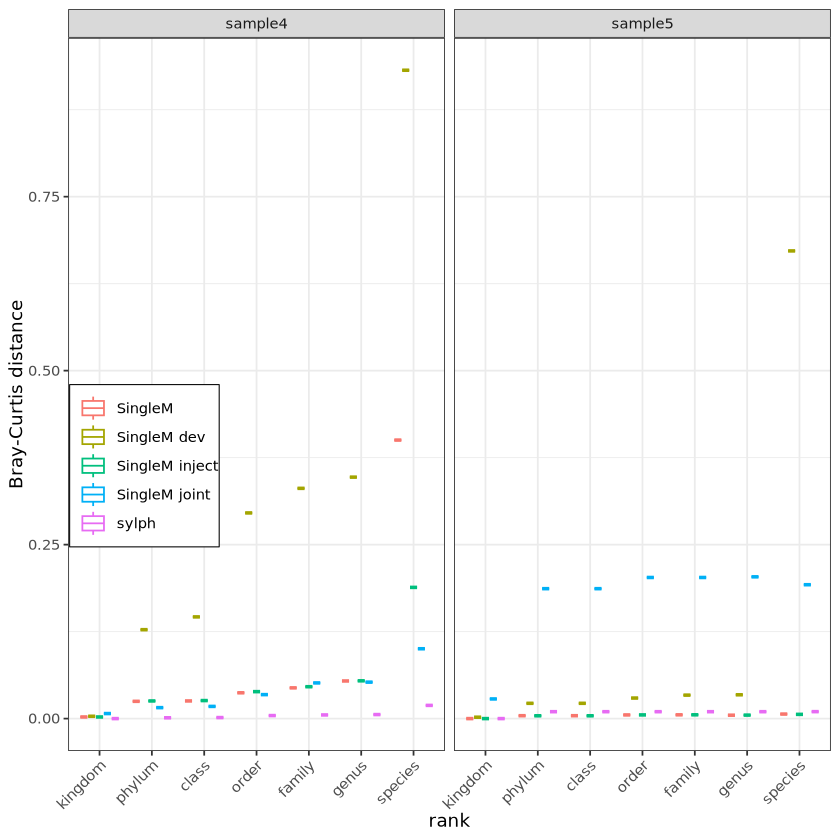

In [ ]:
# Remove figure legend title, and put the legend in bottom left of plot, with a bounding box
ggplot(s1, aes(rank, `Bray-Curtis distance`, colour = tool)) +
   geom_boxplot() +
   scale_x_discrete(na.translate = FALSE) +
   theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
   theme(legend.title=element_blank()) +
   theme(legend.position=c(0.1,0.4)) +
   theme(legend.background = element_rect(colour = "black", linewidth = 0.3)) +
   facet_wrap(vars(community))

# Relationship between relative abundance and accuracy

In [18]:
truth_profiles = data.table(expand.grid(community=communities, dominance=dominance))
truth_profiles2 = truth_profiles[
    ,
    fread(paste('truths/dominance', dominance, '/',community,'.condensed',sep=''),
          colClasses = c("coverage" = "double")),
    by=list(community, dominance)
]
truth_profiles2[, c("sample", "tool") := .(NULL, 'Gold standard')]

In [19]:
tool_profiles = data.table(expand.grid(tool = tools, community = communities, dominance = dominance))
tool_profiles2 = tool_profiles[
    ,
    fread(paste('output_',tool,'/',tool,'/dominance',dominance, '/', community,'.profile',sep='')),
    by=list(tool,community,dominance)
]
tool_profiles2[
    ,
    `:=`(sample = NULL,
         taxonomy = gsub('Root;','',gsub('; ',';',taxonomy)),
         tool = factor(publication_names[tool, on = "tool", publication_name]))
]

all_profiles = rbind(truth_profiles2, tool_profiles2)
all_profiles[, relabu := coverage / sum(coverage), by = list(community, tool)]
m = dcast(all_profiles, taxonomy + community ~ tool, value.var = c("relabu", "coverage"), fill = 0)
setnames(m, names(m), gsub("_", "__", names(m)))
setnames(m, c("relabu__Gold standard", "coverage__Gold standard"), c("true_relabu", "true_coverage"))

In [30]:
# singlem and sylph relative abundances
format_table <- function(m) {
    ra_cols <- grep("^relabu_|_relabu$", names(m), value = TRUE)
    mtmp = m[, which(!grepl("^coverage_|_coverage$", names(m))), with = FALSE]
    mtmp[
        ,
        c(ra_cols, "taxonomy") := c(
            lapply(.SD, scales::label_percent()),
            list(purrr::map_chr(strsplit(taxonomy, "; ?"), function(x) paste0(tail(x,2), collapse = "; ")))
        ),
        .SDcols = ra_cols
    ][order(community, taxonomy)]
}

In [31]:
# singlem coverages
format_table_cov <- function(m) {
    cov_cols <- grep("^coverage_|_coverage$", names(m), value = TRUE)
    mtmp = m[, which(!grepl("^relabu_|_relabu$", names(m))), with = FALSE]
    mtmp[
        ,
        c(cov_cols, "taxonomy") := c(
            .SD,
            list(purrr::map_chr(strsplit(taxonomy, "; ?"), function(x) paste0(tail(x,2), collapse = "; ")))
        ),
        .SDcols = cov_cols
    ][order(community, taxonomy)]
}

In [37]:
# kingdom
#format_table(m[grep("d__", taxonomy), lapply(.SD, sum), by = list(community, taxonomy = gsub(";p__.*", "", taxonomy))])
format_table_cov(m[grep("d__", taxonomy), lapply(.SD, sum), by = list(community, taxonomy = gsub(";p__.*", "", taxonomy))])

community,taxonomy,true_coverage,coverage__SingleM,coverage__SingleM dev,coverage__SingleM inject,coverage__SingleM joint,coverage__sylph
<fct>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
sample4,d__Archaea,0.0,0.42,0.59,0.42,1.01,0.000
sample4,d__Bacteria,180.0,178.98,175.89,178.97,138.44,190.606
sample5,d__Archaea,0.0,0.00,2.72,0.00,6.06,0.000
sample5,d__Bacteria,1367.2,1364.53,1360.02,1364.70,208.47,1382.238


In [38]:
# phylum
#format_table(m[!grepl("d__Archaea", taxonomy) & grepl(";p__", taxonomy), lapply(.SD, sum), by = list(community, taxonomy = gsub(";c__.*", "", taxonomy))])
format_table_cov(m[!grepl("d__Archaea", taxonomy) & grepl(";p__", taxonomy), lapply(.SD, sum), by = list(community, taxonomy = gsub(";c__.*", "", taxonomy))])

community,taxonomy,true_coverage,coverage__SingleM,coverage__SingleM dev,coverage__SingleM inject,coverage__SingleM joint,coverage__sylph
<fct>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
sample4,d__Bacteria; p__Actinobacteriota,102.0,105.01,94.98,105.00,79.56,107.941
sample4,d__Bacteria; p__Campylobacterota,3.0,2.66,0.04,2.66,2.22,3.098
sample4,d__Bacteria; p__Chloroflexota,0.0,0.00,0.00,0.00,0.06,0.000
sample4,d__Bacteria; p__Cyanobacteria,3.0,2.44,0.43,2.44,2.41,3.170
sample4,d__Bacteria; p__Desulfobacterota,6.0,5.74,0.46,5.74,4.94,6.413
sample4,d__Bacteria; p__Firmicutes,12.0,12.22,7.90,12.42,8.78,12.779
sample4,d__Bacteria; p__Firmicutes_A,9.0,9.05,3.44,9.05,6.47,9.529
sample4,d__Bacteria; p__Firmicutes_C,3.0,2.10,0.00,2.10,1.45,3.144
sample4,d__Bacteria; p__Planctomycetota,0.0,0.00,0.00,0.00,0.15,0.000


In [39]:
# class
#format_table(m[!grepl("d__Archaea", taxonomy) & grepl(";c__", taxonomy), lapply(.SD, sum), by = list(community, taxonomy = gsub(";o__.*", "", taxonomy))])
format_table_cov(m[!grepl("d__Archaea", taxonomy) & grepl(";c__", taxonomy), lapply(.SD, sum), by = list(community, taxonomy = gsub(";o__.*", "", taxonomy))])

community,taxonomy,true_coverage,coverage__SingleM,coverage__SingleM dev,coverage__SingleM inject,coverage__SingleM joint,coverage__sylph
<fct>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
sample4,p__Actinobacteriota; c__Actinomycetia,102.0,105.01,94.98,105.00,79.56,107.941
sample4,p__Campylobacterota; c__Campylobacteria,3.0,2.66,0.04,2.66,2.22,3.098
sample4,p__Chloroflexota; c__Dehalococcoidia,0.0,0.00,0.00,0.00,0.06,0.000
sample4,p__Cyanobacteria; c__Cyanobacteriia,3.0,2.44,0.43,2.44,2.41,3.170
sample4,p__Desulfobacterota; c__Desulfarculia,0.0,0.00,0.00,0.00,0.07,0.000
sample4,p__Desulfobacterota; c__Desulfomonilia,3.0,2.96,0.46,2.96,2.40,3.200
sample4,p__Desulfobacterota; c__Thermodesulfobacteria,3.0,2.67,0.00,2.67,2.47,3.213
sample4,p__Firmicutes; c__Bacilli,12.0,12.22,7.90,12.42,8.78,12.779
sample4,p__Firmicutes_A; c__Clostridia,9.0,9.05,3.44,9.05,6.47,9.529


In [40]:
# order
#format_table(m[!grepl("d__Archaea", taxonomy) & grepl(";o__", taxonomy), lapply(.SD, sum), by = list(community, taxonomy = gsub(";f__.*", "", taxonomy))])
format_table_cov(m[!grepl("d__Archaea", taxonomy) & grepl(";o__", taxonomy), lapply(.SD, sum), by = list(community, taxonomy = gsub(";f__.*", "", taxonomy))])

community,taxonomy,true_coverage,coverage__SingleM,coverage__SingleM dev,coverage__SingleM inject,coverage__SingleM joint,coverage__sylph
<fct>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
sample4,c__Actinomycetia; o__Actinomycetales,12.0,13.40,1.05,13.40,9.78,12.409
sample4,c__Actinomycetia; o__Streptomycetales,90.0,88.54,81.39,88.53,69.78,95.532
sample4,c__Alphaproteobacteria; o__Rhizobiales,6.0,6.59,0.07,6.59,4.57,6.449
sample4,c__Alphaproteobacteria; o__Rhizobiales_A,3.0,2.22,0.00,2.22,2.06,3.233
sample4,c__Bacilli; o__Bacillales_A,3.0,2.67,0.07,2.67,2.51,3.287
sample4,c__Bacilli; o__Lactobacillales,9.0,9.15,2.81,9.75,6.27,9.492
sample4,c__Campylobacteria; o__Campylobacterales,3.0,2.66,0.04,2.66,2.22,3.098
sample4,c__Clostridia; o__Clostridiales,6.0,6.15,1.38,6.15,4.72,6.361
sample4,c__Clostridia; o__Lachnospirales,3.0,2.79,0.00,2.79,1.69,3.168


In [41]:
# family
#format_table(m[!grepl("d__Archaea", taxonomy) & grepl(";f__", taxonomy), lapply(.SD, sum), by = list(community, taxonomy = gsub(";g__.*", "", taxonomy))])
format_table_cov(m[!grepl("d__Archaea", taxonomy) & grepl(";f__", taxonomy), lapply(.SD, sum), by = list(community, taxonomy = gsub(";g__.*", "", taxonomy))])

community,taxonomy,true_coverage,coverage__SingleM,coverage__SingleM dev,coverage__SingleM inject,coverage__SingleM joint,coverage__sylph
<fct>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
sample4,o__Acidaminococcales; f__Acidaminococcaceae,3.0,2.10,0.00,2.10,1.45,3.144
sample4,o__Actinomycetales; f__Bifidobacteriaceae,3.0,2.56,0.00,2.56,1.94,3.088
sample4,o__Actinomycetales; f__Dermatophilaceae,3.0,2.73,0.00,2.73,2.62,3.213
sample4,o__Actinomycetales; f__Microbacteriaceae,3.0,3.12,0.00,3.12,2.54,3.132
sample4,o__Actinomycetales; f__Micrococcaceae,3.0,3.80,0.00,3.80,2.68,2.976
sample4,o__Bacillales_A; f__Planococcaceae,3.0,2.67,0.07,2.67,2.51,3.287
sample4,o__Burkholderiales; f__Burkholderiaceae,3.0,2.72,0.00,2.72,2.28,3.047
sample4,o__Burkholderiales; f__Rhodocyclaceae,3.0,1.42,0.00,1.42,1.41,3.121
sample4,o__CAIUCS01; f__CAIUCS01,3.0,2.44,0.43,2.44,2.41,3.170


In [42]:
# How well does genus level rescue some of the missing genomes? First need to remake the table with genus level, annoying since kraken profiles are filled, when the rest aren't.
#format_table(m[!grepl("d__Archaea", taxonomy) & grepl(";g__", taxonomy), lapply(.SD, sum), by = list(community, taxonomy = gsub(";s__.*", "", taxonomy))])
format_table_cov(m[!grepl("d__Archaea", taxonomy) & grepl(";g__", taxonomy), lapply(.SD, sum), by = list(community, taxonomy = gsub(";s__.*", "", taxonomy))])

community,taxonomy,true_coverage,coverage__SingleM,coverage__SingleM dev,coverage__SingleM inject,coverage__SingleM joint,coverage__sylph
<fct>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
sample4,f__AB-539-J10; g__RBG-13-51-36,0.0,0.00,0.00,0.00,0.06,0.000
sample4,f__Acidaminococcaceae; g__Succiniclasticum,3.0,2.10,0.00,2.10,1.45,3.144
sample4,f__Bifidobacteriaceae; g__Bifidobacterium,3.0,2.56,0.00,2.56,1.94,3.088
sample4,f__Burkholderiaceae; g__Achromobacter,3.0,2.67,0.00,2.67,2.28,3.047
sample4,f__CAIMTB01; g__CAIMTB01,3.0,2.16,0.00,2.16,2.10,3.141
sample4,f__CAIUCS01; g__CAIUCS01,3.0,2.44,0.43,2.44,2.41,3.170
sample4,f__Clostridiaceae; g__Clostridium,3.0,3.15,0.00,3.15,2.39,3.284
sample4,f__Clostridiaceae; g__Clostridium_T,3.0,2.75,0.00,2.75,2.33,3.077
sample4,f__DSYF01; g__DSYF01,0.0,0.00,0.00,0.00,0.06,0.000


In [43]:
# Species level
#format_table(m[!grepl("d__Archaea", taxonomy) & grepl(";s__", taxonomy)])
format_table_cov(m[!grepl("d__Archaea", taxonomy) & grepl(";s__", taxonomy)])

taxonomy,community,true_coverage,coverage__SingleM,coverage__SingleM dev,coverage__SingleM inject,coverage__SingleM joint,coverage__sylph
<chr>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
g__Accumulibacter; s__Accumulibacter phosphatis_C,sample4,3e+00,1.11,0.00,1.11,1.39,3.121
g__Acetatifactor; s__Acetatifactor sp900066565,sample4,3e+00,1.57,0.00,1.57,1.69,3.168
g__Acetatifactor; s__Acetatifactor sp900771995,sample4,0e+00,0.56,0.00,0.56,0.00,0.000
g__Achromobacter; s__Achromobacter dolens,sample4,3e+00,2.48,0.00,2.48,2.28,3.047
g__Bifidobacterium; s__Bifidobacterium catenulatum,sample4,3e+00,1.83,0.00,1.83,1.94,3.088
g__Bifidobacterium; s__Bifidobacterium kashiwanohense,sample4,0e+00,0.42,0.00,0.42,0.00,0.000
g__Bradyrhizobium; s__Bradyrhizobium sp900114915,sample4,3e+00,2.84,0.01,2.84,2.74,3.181
g__CAIMTB01; s__CAIMTB01 sp903844265,sample4,3e+00,2.16,0.00,2.16,2.10,3.141
g__CAIUCS01; s__CAIUCS01 sp903897715,sample4,3e+00,2.44,0.43,2.44,2.41,3.170
